In [1]:
import pandas as pd
from Bio import SeqIO
from collections import defaultdict
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from tqdm.notebook import tqdm

### Load FASTA and GFF3

In [2]:
# GFF3 from Ensembl Genomes
gff_file = "../dependencies/Homo_sapiens.GRCh38.114.gff3"
# hg38 fasta from UCSC
fasta_file = "../dependencies/GRCh38.p14.genome.fa"

In [3]:
fasta_index = SeqIO.to_dict(SeqIO.parse(fasta_file, "fasta"))

In [4]:
def load_gff_preserve_attributes(gff_file):
    return pd.read_csv(
        gff_file,
        sep="\t",
        comment="#",
        header=None,
        dtype=str,
        quoting=csv.QUOTE_NONE,
        names=[
            "seqid", "source", "type", "start", "end", "score",
            "strand", "phase", "attributes"
        ],
    )

In [5]:
def extract_attr(attr_str, key):
    # Extracts a single attribute from GFF attributes column
    for part in attr_str.split(";"):
        if part.startswith(key + "="):
            return part.split("=", 1)[1]
    return None
    
def parse_attributes(df):
    for k in ["ID", "Parent", "biotype", "tag"]:
        df[k] = df["attributes"].apply(lambda x: extract_attr(x, k))
        
    df["ID_stripped"] = df["ID"].fillna("").str.split(":", n=1).str[-1]
    df["Parent_stripped"] = df["Parent"].fillna("").str.split(":", n=1).str[-1]
    
    return df

In [6]:
gff = load_gff_preserve_attributes(gff_file)
gff = parse_attributes(gff)

gff["start"] = gff["start"].astype(int)
gff["end"] = gff["end"].astype(int)

#### Filter to chromosomes only

In [7]:
def is_chromosome(seqid):
    return bool(re.match(r'^(chr)?([1-9]|1[0-9]|2[0-2]|X|Y)$', str(seqid)))

def prepend_chr(seqid):
    seqid = str(seqid)
    return seqid if seqid.startswith("chr") else f"chr{seqid}"

In [8]:
# Filter to chr only
gff_chr_df = gff[gff["seqid"].apply(is_chromosome)]

# UCSC FASTA has chr<...> format, so edit the GFF DF to also include the chr prefix
gff_chr_df["seqid"] = gff_chr_df["seqid"].apply(prepend_chr)

/tmp/ipykernel_898011/3065856239.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_chr_df["seqid"] = gff_chr_df["seqid"].apply(prepend_chr)


#### Filter to Ensembl Canonical, Long-non-coding RNA Transcripts

In [9]:
# List of lncRNA genes
lncRNA_gene_ids = gff_chr_df[
    (gff_chr_df["type"] == "ncRNA_gene") &
    (gff_chr_df["biotype"] == "lncRNA")
]["ID_stripped"].unique()

# List of Ensembl Canonical Transcripts only
canonical_mask = gff_chr_df["tag"].str.contains("Ensembl_canonical", na=False)
canonical_tx_ids = gff_chr_df[
    (gff_chr_df["type"] == "lnc_RNA") &
    (gff_chr_df["biotype"] == "lncRNA") &
    (gff_chr_df["ID_stripped"].notnull()) &
    (gff_chr_df["ID_stripped"] != "") &
    (canonical_mask) &
    (gff_chr_df["Parent_stripped"].isin(lncRNA_gene_ids))
]["ID_stripped"].unique()

# Remove intronless transcripts
lncRNA_exon_counts = gff_chr_df[
    (gff_chr_df["type"] == "exon") &
    (gff_chr_df["Parent_stripped"].isin(canonical_tx_ids))
].groupby("Parent_stripped").size()

lncRNA_multi_exon_tx_ids = lncRNA_exon_counts[lncRNA_exon_counts > 1].index
# Get all transcripts (and their child features and parent genes) 
# in the intron-containing, lncRNA Ensembl Canonical subset
lncRNA_subset = gff_chr_df[
    (gff_chr_df["ID_stripped"].isin(lncRNA_gene_ids)) |
    (gff_chr_df["ID_stripped"].isin(lncRNA_multi_exon_tx_ids)) |
    (gff_chr_df["Parent_stripped"].isin(lncRNA_multi_exon_tx_ids))
]

In [10]:
print("Number of lncRNA genes", len(lncRNA_gene_ids))
print("Number of lncRNA Ensembl Canonical transcripts", len(canonical_tx_ids))
print("Number of lncRNA Ensembl Canonical intron-containing transcripts", len(lncRNA_multi_exon_tx_ids))
print("Number of features in lncRNA subset", len(lncRNA_subset))

Number of lncRNA genes 34882
Number of lncRNA Ensembl Canonical transcripts 34846
Number of lncRNA Ensembl Canonical intron-containing transcripts 30600
Number of features in lncRNA subset 161079


#### Filter to MANE Select, Protein-Coding Transcripts

In [11]:
# List of protein coding genes (type == gene and biotype == protein_coding)
protein_coding_gene_ids = gff_chr_df[
    (gff_chr_df["type"] == "gene") &
    (gff_chr_df["biotype"] == "protein_coding")
]["ID_stripped"].unique()

# List of MANE Select Transcripts, Protein Coding only (MANE Select has a few lncRNA transcripts too)
mane_mask = gff_chr_df["tag"].str.contains("MANE_Select", na=False)
mane_tx_ids = gff_chr_df[
    (gff_chr_df["type"].str.contains("transcript|rna", case=False)) &  # all transcript types
    (gff_chr_df["biotype"] == "protein_coding") &
    (gff_chr_df["ID_stripped"].notnull()) &
    (gff_chr_df["ID_stripped"] != "") &
    (mane_mask) &
    (gff_chr_df["Parent_stripped"].isin(protein_coding_gene_ids))
]["ID_stripped"].unique()

# Remove intronless transcripts
exon_counts = gff_chr_df[
    (gff_chr_df["type"] == "exon") &
    (gff_chr_df["Parent_stripped"].isin(mane_tx_ids))
].groupby("Parent_stripped").size()

multi_exon_tx_ids = exon_counts[exon_counts > 1].index

# Get all transcripts (and their child features and parent genes) 
# in the intron-containing, protein-coding MANE Select subset
protein_coding_subset = gff_chr_df[
    (gff_chr_df["ID_stripped"].isin(protein_coding_gene_ids)) |
    (gff_chr_df["ID_stripped"].isin(multi_exon_tx_ids)) |
    (gff_chr_df["Parent_stripped"].isin(multi_exon_tx_ids))
]

In [12]:
print("Number of protein coding genes", len(protein_coding_gene_ids))
print("Number of protein coding MANE Select transcripts", len(mane_tx_ids))
print("Number of protein coding MANE Select intron-containing transcripts", len(multi_exon_tx_ids))
print("Number of features in protein coding subset", len(protein_coding_subset))

Number of protein coding genes 20083
Number of protein coding MANE Select transcripts 19226
Number of protein coding MANE Select intron-containing transcripts 18150
Number of features in protein coding subset 476155


### Sequence Region Categorization

In [13]:
regions = [
    "exon",
    "intron",
]

In [14]:
def get_sequence(chrom, start, end, strand):
    seq = fasta_index[chrom].seq[start-1:end]
    if strand == '-':
        seq = seq.reverse_complement()
    return str(seq)

In [15]:
def _interval_contains(a_start, a_end, b_start, b_end):
    # Returns whether (b_start, b_end) is fully contained in (a_start, a_end)
    assert a_start <= a_end
    assert b_start <= b_end
    
    return (a_start <= b_start) and (b_end <= a_end)

In [16]:
def get_introns(exons, positive_strand):
    introns = []
    group = exons.sort_values("start", ascending=True)
    for (prev_end, next_start) in zip(group["end"].iloc[:-1], group["start"].iloc[1:]):
        assert next_start > prev_end + 1
        introns.append({
            "seqid": group["seqid"].iloc[0],
            "start": prev_end + 1,
            "end": next_start - 1,
            "strand": group["strand"].iloc[0],
            "type": "intron"
        })

    intron_df = pd.DataFrame(introns)
    return intron_df.sort_values("start", ascending=positive_strand)

    return pd.DataFrame(introns)

In [17]:
def classify_regions(df, positive_strand, feature="exon"):
    out = {}
    n = len(df)
    if n == 0:
        return out

    df = df.sort_values("start", ascending=positive_strand).reset_index(drop=True)
    out[feature] = [df.loc[i] for i in range(n)]

    return out

In [18]:
def assign_transcript_regions(df):
    transcripts = df.loc[df["type"].isin(["lnc_RNA", "mRNA"])] \
                    .copy() \
                    .reset_index(drop=True)
    for region in regions:
        transcripts[region] = ""

    for tx_id, tx in tqdm(transcripts.iterrows()):
        parent_id = tx.ID
        positive_strand = tx.strand == "+"

        # --- Exons
        exons = df[(df["type"]=="exon") & (df["Parent"]==parent_id)]
        exon_regions = classify_regions(exons, positive_strand, "exon")
        for region, feats in exon_regions.items():
            seqs = [get_sequence(r.seqid, r.start, r.end, r.strand) for r in feats]
            transcripts.at[tx_id, region] = "|".join(seqs) if seqs else None

        # --- Introns
        introns = get_introns(exons, positive_strand)
        intron_regions = classify_regions(introns, positive_strand, "intron")
        for region, feats in intron_regions.items():
            seqs = [get_sequence(r.seqid, r.start, r.end, r.strand) for r in feats]
            transcripts.at[tx_id, region] = "|".join(seqs) if seqs else None
            
    return transcripts

In [19]:
annotated_transcripts = assign_transcript_regions(protein_coding_subset.reset_index())

0it [00:00, ?it/s]

In [20]:
annotated_lncRNA_transcripts = assign_transcript_regions(lncRNA_subset.reset_index())

0it [00:00, ?it/s]

In [21]:
annotated_regions_exploded = dict()

for name, df in [("lncRNA", annotated_lncRNA_transcripts), ("protein_coding", annotated_transcripts)]:
    df["exon_list"] = df["exon"].str.split("|")
    df["intron_list"] = df["intron"].str.split("|")
    
    annotated_regions_exploded[f"{name}_exon"] = df[[
        "seqid", "source", "type", "start", "end", "strand", "attributes", "ID", "Parent",
        "biotype", "tag", "ID_stripped", "Parent_stripped", "exon_list"
    ]].explode("exon_list").reset_index()
    
    annotated_regions_exploded[f"{name}_intron"] = df[[
        "seqid", "source", "type", "start", "end", "strand", "attributes", "ID", "Parent",
        "biotype", "tag", "ID_stripped", "Parent_stripped", "intron_list"
    ]].explode("intron_list").reset_index()

In [22]:
def GC_content(x):
    if type(x) != str:
        return np.NaN
    return (x.upper().count("C") + x.upper().count("G")) / len(x)

def CpG_obs(x):
    if type(x) != str:
        return np.NaN
    return x.upper().count("CG")

def CpG_exp(x):
    if type(x) != str:
        return np.NaN
    return (x.upper().count("C") * x.upper().count("G")) / (len(x))

def CpG_obs_exp_ratio(x):
    if type(x) != str:
        return np.NaN

    obs = CpG_obs(x)
    exp = CpG_exp(x)
    if obs == 0:
        return np.NaN
    return obs / exp
        

for df, col in [
    (annotated_regions_exploded["lncRNA_exon"], "exon_list"),
    (annotated_regions_exploded["lncRNA_intron"], "intron_list"),
    (annotated_regions_exploded["protein_coding_exon"], "exon_list"),
    (annotated_regions_exploded["protein_coding_intron"], "intron_list")
]:
    df[f"feature_GC_content"] = df[col].apply(GC_content)
    df[f"feature_CpG_obs"] = df[col].apply(CpG_obs)
    df[f"feature_CpG_exp"] = df[col].apply(CpG_exp)    
    df[f"feature_CpG_obs_exp_ratio"] = df[col].apply(CpG_obs_exp_ratio)

In [25]:
def plot_cpg_ratios(
    dfs,
    labels,
    column_name="Score",
    title="Plot",
    dpi=300,
    figsize=(6, 3),
):
    if len(dfs) != len(labels):
        raise ValueError("Length of dfs and labels must match.")

    # Combine all dataframes into long format
    long_dfs = []
    for df, label in zip(dfs, labels):
        col = df.columns[0]  # assume one column
        tmp = df.rename(columns={col: column_name}).copy()
        tmp["Dataset"] = label
        long_dfs.append(tmp)
    df_long = pd.concat(long_dfs, ignore_index=True)

    counts = df_long.groupby("Dataset").size().reset_index(name="n")
    counts_dict = dict(zip(counts["Dataset"], counts["n"]))

    df_long["DatasetLabel"] = df_long["Dataset"]
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    sns.boxplot(
        data=df_long,
        y="DatasetLabel",
        x=column_name,
        palette="tab10",
        ax=ax,
        fliersize=0
    )

    ax.set_xlabel("CpG Ratio")
    ax.set_ylabel("")
    ax.set_xlim(-0.05, 1.5)
    fig.suptitle(title)
    ax.legend_.remove() if ax.get_legend() else None  # Remove legend if present

    # Add n= counts aligned to the right of boxplots
    xlim = ax.get_xlim()
    x_text_position = xlim[1] + (xlim[1] - xlim[0]) * 0.02  # Slightly right of plot edge

    for i, label in enumerate(labels):
        count = counts_dict[label]
        ax.text(x_text_position, i, f"n={count}",
                va='center', ha='left',
                fontsize=9)

    for tick in ax.get_yticklabels():
        tick.set_horizontalalignment('right')
        tick.set_multialignment('center')

    return fig, ax

/tmp/ipykernel_898011/1616048341.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


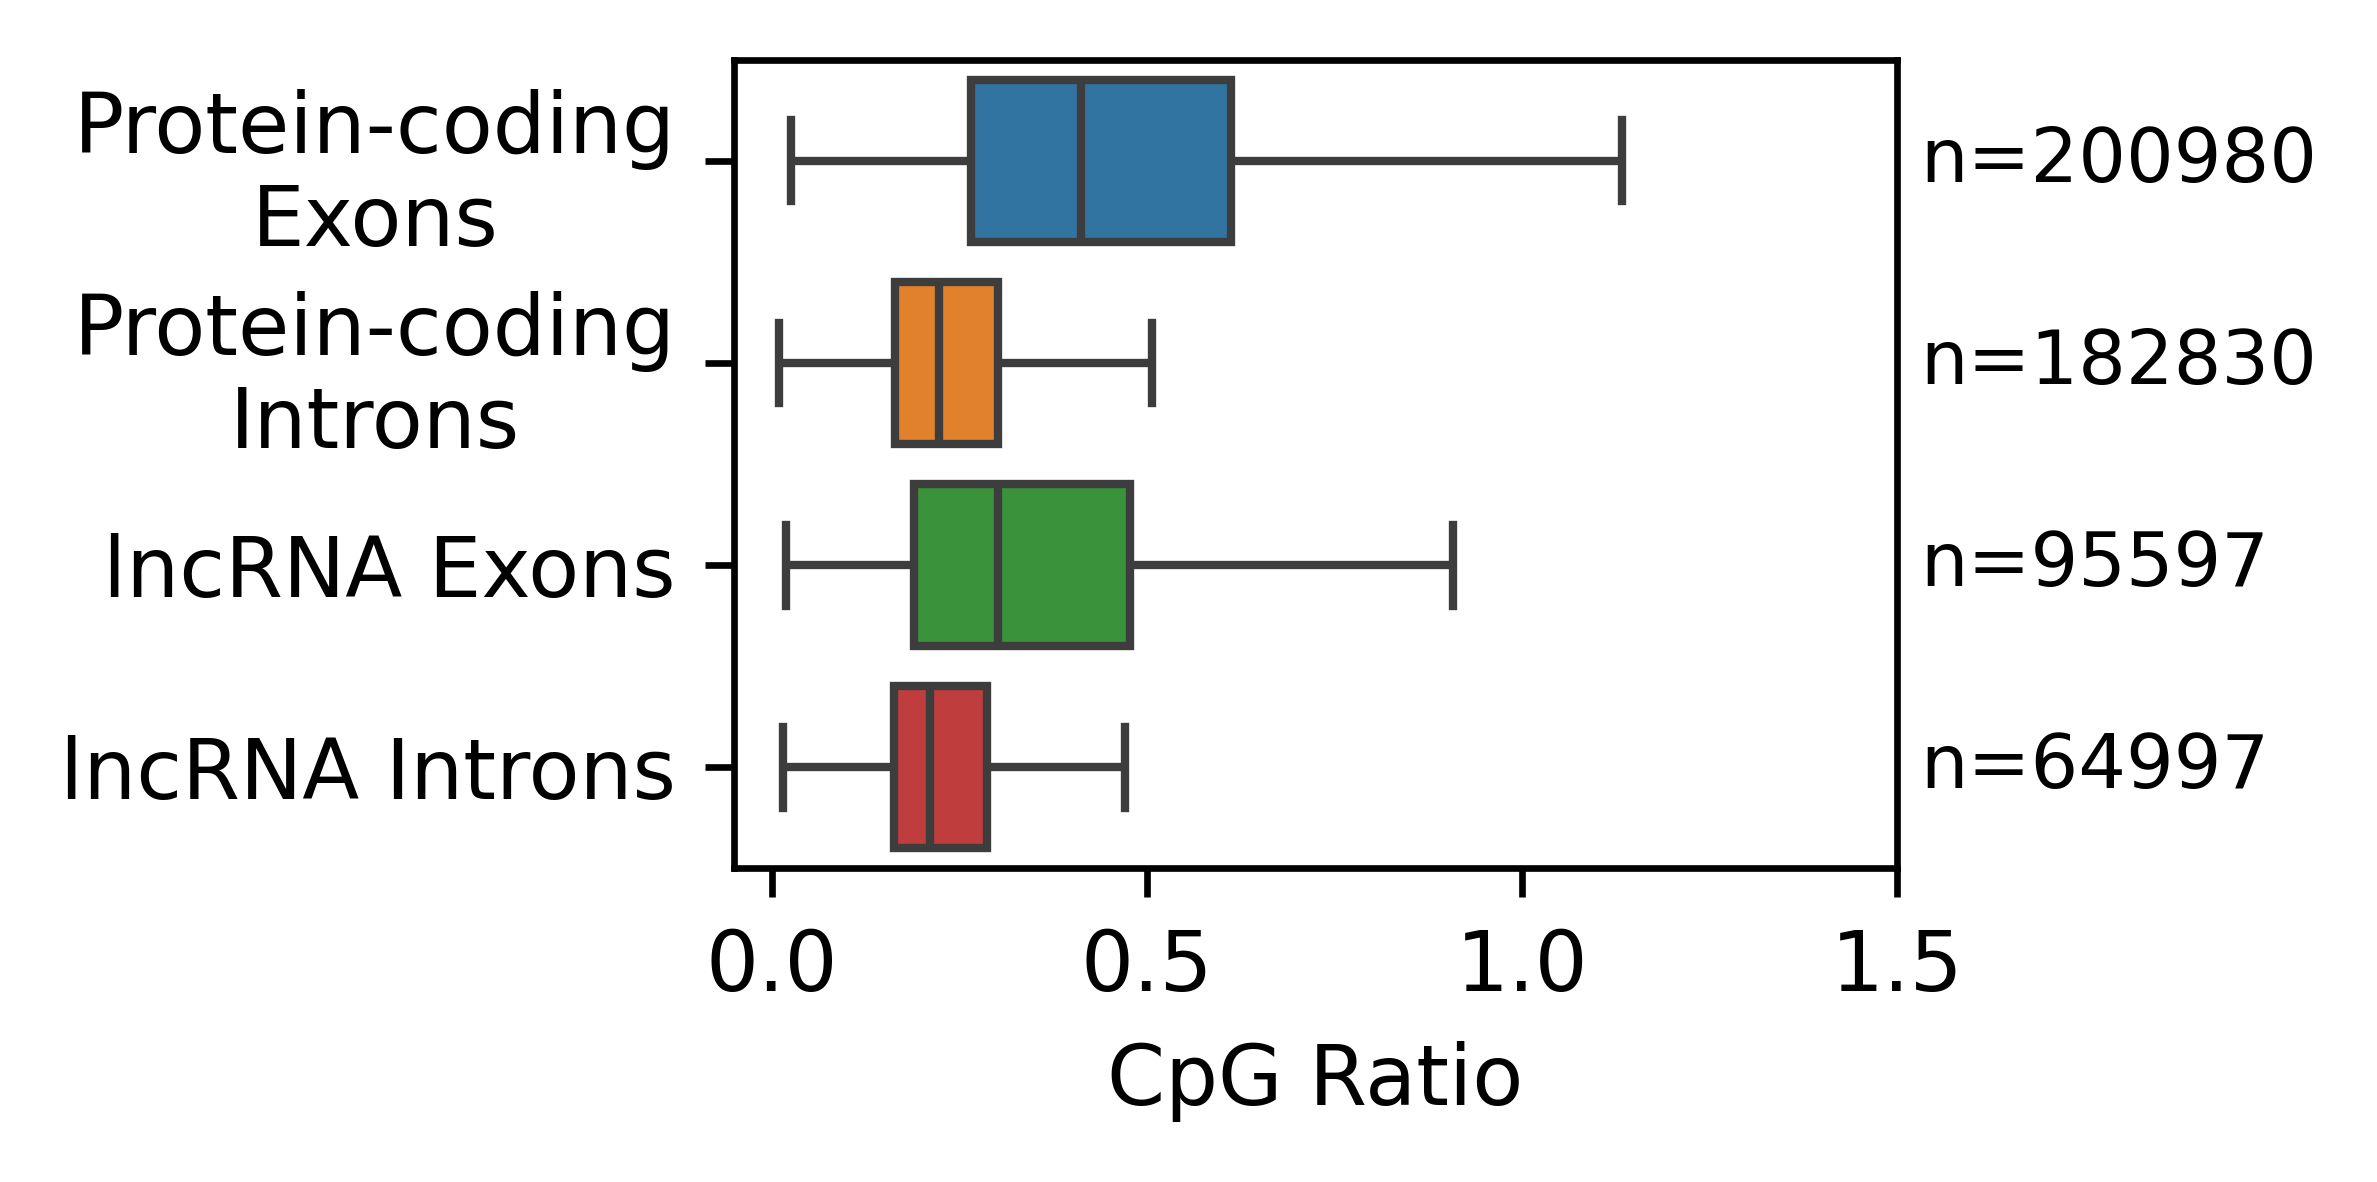

In [26]:
fig, ax = plot_cpg_ratios(
    dfs=[
        annotated_regions_exploded["protein_coding_exon"][["feature_CpG_obs_exp_ratio"]], 
        annotated_regions_exploded["protein_coding_intron"][["feature_CpG_obs_exp_ratio"]], 
        annotated_regions_exploded["lncRNA_exon"][["feature_CpG_obs_exp_ratio"]], 
        annotated_regions_exploded["lncRNA_intron"][["feature_CpG_obs_exp_ratio"]]
    ],
    labels=[
        "Protein-coding\nExons", 
        "Protein-coding\nIntrons", 
        "lncRNA Exons", 
        "lncRNA Introns"
    ],
    column_name="feature_CpG_obs_exp_ratio",
    title="",
    dpi=600,
    figsize=(2.5, 1.75),
)
fig.savefig("figures/EnsemblGenomicFeatures_CpGRatio.svg", dpi=600)